In [283]:
import pandas as pd
import os
from matplotlib import pylab as plt
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [284]:
BASE_DIR = os.path.dirname(os.getcwd())

df = pd.read_csv(os.path.join(BASE_DIR, "data","processed", "cleaned_europe_sales.csv"))

df

,Region,Country,Item Type,Sales Channel,Order Priority,Order Date,Date,Order ID,Ship Date,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit
0,Europe,Czech Republic,Beverages,Offline,C,2011-09-12,2010-01-01,478051030,2011-09-29,4778,47.45,31.79,226716.10,151892.62,74823.48
1,Europe,Bosnia and Herzegovina,Clothes,Online,M,2013-10-14,2010-02-01,919133651,2013-11-04,927,109.28,35.84,101302.56,33223.68,68078.88
2,Europe,Austria,Cereal,Offline,C,2014-08-13,2010-03-01,987410676,2014-09-06,5616,205.70,117.11,1155211.20,657689.76,497521.44
3,Europe,Bulgaria,Office Supplies,Online,L,2010-10-31,2010-04-01,672330081,2010-11-29,6266,651.21,524.96,4080481.86,3289399.36,791082.50
4,Europe,Estonia,Fruits,Online,L,2016-09-28,2010-05-01,579463422,2016-11-01,4958,9.33,6.92,46258.14,34309.36,11948.78
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1325,Europe,Norway,Personal Care,Offline,M,2014-01-14,2013-08-18,634033286,2014-01-15,3394,81.73,56.67,277391.62,192337.98,85053.64
1326,Europe,Ukraine,Cereal,Offline,L,2014-04-14,2013-08-19,559183347,2014-05-21,3633,205.70,117.11,747308.10,425460.63,321847.47
1327,Europe,Armenia,Meat,Offline,M,2015-11-09,2013-08-20,781416594,2015-12-23,7390,421.89,364.69,3117767.10,2695059.10,422708.00
1328,Europe,Denmark,Clothes,Offline,H,2012-05-09,2013-08-21,713357150,2012-06-03,7088,109.28,35.84,774576.64,254033.92,520542.72


In [285]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Region          1330 non-null   str    
 1   Country         1330 non-null   str    
 2   Item Type       1330 non-null   str    
 3   Sales Channel   1330 non-null   str    
 4   Order Priority  1330 non-null   str    
 5   Order Date      1330 non-null   str    
 6   Date            1330 non-null   str    
 7   Order ID        1330 non-null   int64  
 8   Ship Date       1330 non-null   str    
 9   Units Sold      1330 non-null   int64  
 10  Unit Price      1330 non-null   float64
 11  Unit Cost       1330 non-null   float64
 12  Total Revenue   1330 non-null   float64
 13  Total Cost      1330 non-null   float64
 14  Total Profit    1330 non-null   float64
dtypes: float64(5), int64(2), str(8)
memory usage: 156.0 KB


In [286]:
df['Order Date']= pd.to_datetime(df['Order Date'],format='mixed')

df = df.set_index('Order Date').sort_index()

sales_daily = df['Total Revenue'].resample('D').sum()
sales_monthly = df['Total Revenue'].resample('ME').sum()
sales_yearly = df['Total Revenue'].resample('YE').sum()

sales_daily

Order Date
2010-01-01    3965224.16
2010-01-02          0.00
2010-01-03      34204.64
2010-01-04          0.00
2010-01-05          0.00
                 ...    
2017-07-19          0.00
2017-07-20    3843862.40
2017-07-21          0.00
2017-07-22     320265.42
2017-07-23    1061935.58
Freq: D, Name: Total Revenue, Length: 2761, dtype: float64

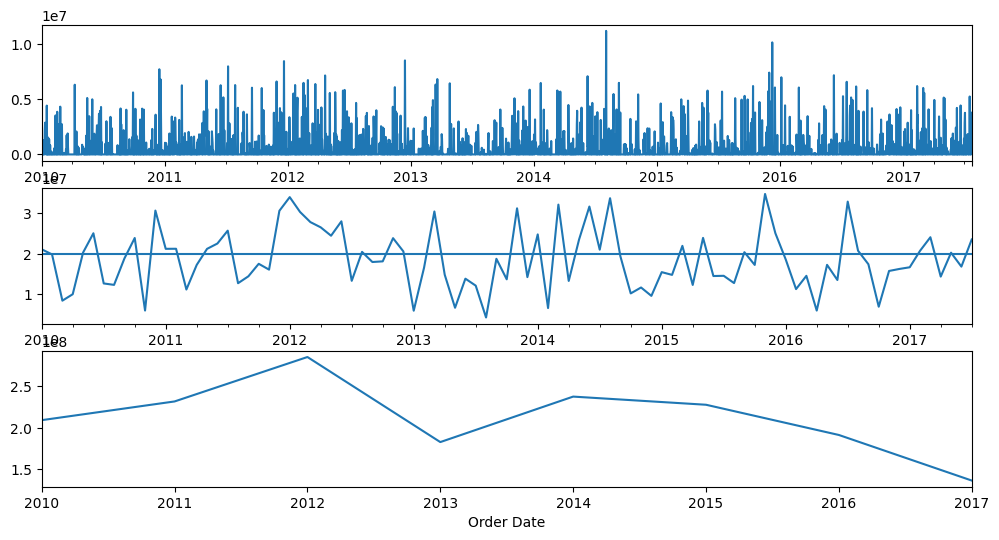

In [287]:
plt.figure(figsize=(12,6))

plt.subplot(311)
sales_daily.plot()
# plt.axhline(y=20000000)

plt.subplot(312)
sales_monthly.plot()
plt.axhline(y=20000000)

plt.subplot(313)
sales_yearly.plot()

plt.show()

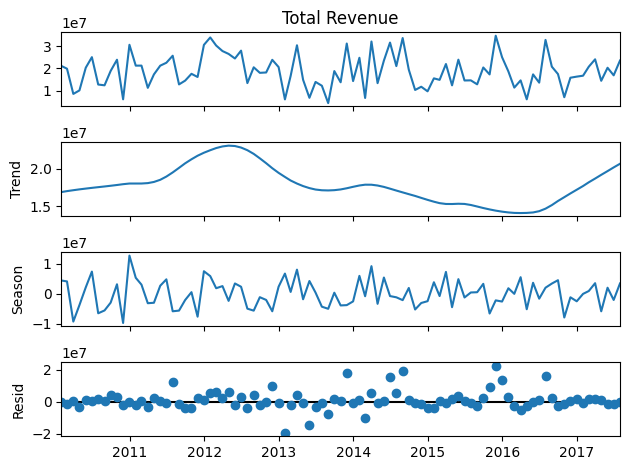

In [288]:
sales_decompo = STL(sales_monthly,period=12,robust=True).fit()

sales_decompo.plot()

plt.show()



In [289]:
sales_monthly_observed = sales_decompo.observed
sales_monthly_trend = sales_decompo.trend
sales_monthly_seasonal = sales_decompo.seasonal
sales_monthly_resid = sales_decompo.resid

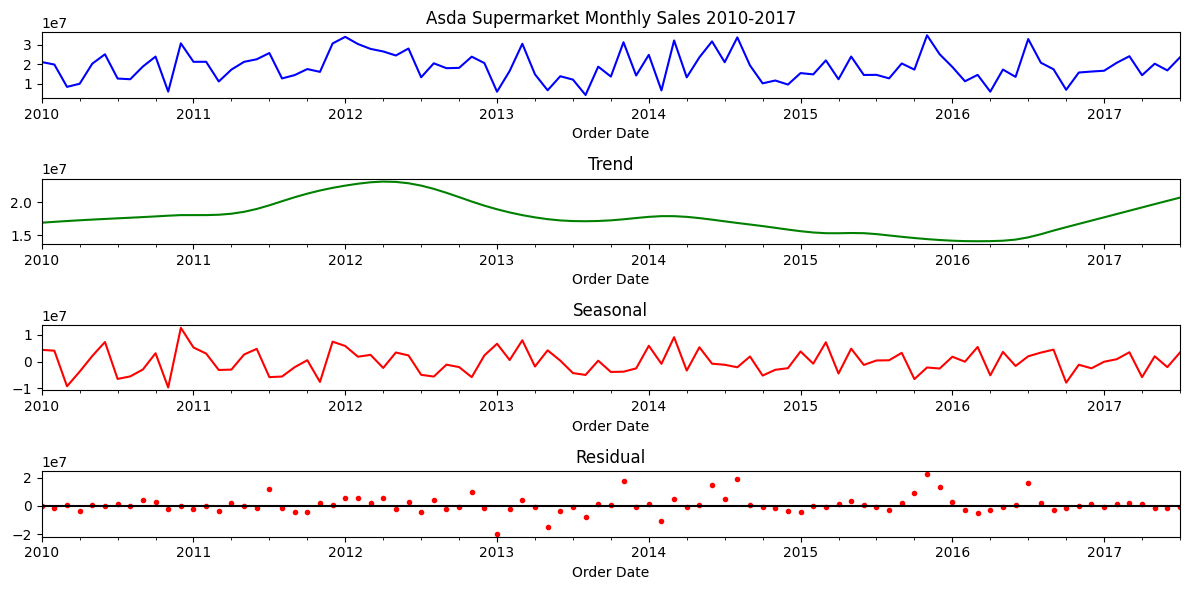

In [290]:
plt.figure(figsize=(12,6))

plt.subplot(4,1,1)
sales_monthly_observed.plot(color='blue')
plt.title("Asda Supermarket Monthly Sales 2010-2017")

plt.subplot(4,1,2)
sales_monthly_trend.plot(color='g')
plt.title("Trend")

plt.subplot(4,1,3)
sales_monthly_seasonal.plot(color='red')
plt.title("Seasonal")

plt.subplot(4,1,4)
sales_monthly_resid.plot(style='.', color='red')
plt.axhline(y=0, color='black')
plt.title("Residual")


plt.tight_layout()
plt.show()

In [295]:
seasonal_df = sales_monthly_seasonal.to_frame(name='seasonal')

# extract month
seasonal_df['month'] = seasonal_df.index.month

# average seasonal value per month
monthly_pattern = seasonal_df.groupby('month')['seasonal'].mean()

print(monthly_pattern.sort_values(ascending=False))



month
1     4.214301e+06
5     3.527500e+06
3     2.934011e+06
12    1.751802e+06
6     1.123150e+06
2     1.084446e+06
9     5.320086e+05
7    -2.142783e+06
8    -2.887703e+06
10   -3.168787e+06
4    -3.754194e+06
11   -4.806520e+06
Name: seasonal, dtype: float64


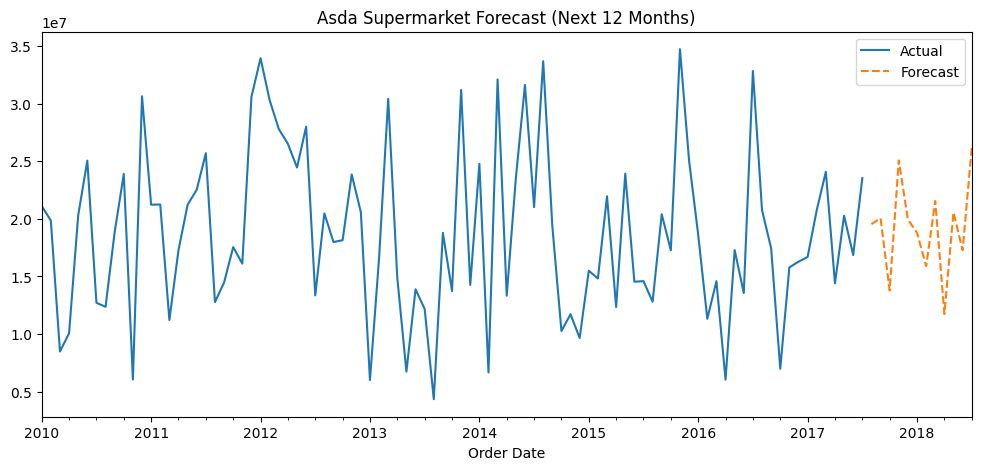

In [291]:
# ==============================
# 2. Build Model (SARIMA)
# ==============================
model = SARIMAX(
    sales_monthly,
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

results = model.fit()

# ==============================
# 3. Forecast (next 12 months)
# ==============================
forecast = results.get_forecast(steps=12)
forecast_values = forecast.predicted_mean

# ==============================
# 4. Plot
# ==============================
plt.figure(figsize=(12,5))

sales_monthly.plot(label='Actual')
forecast_values.plot(label='Forecast', linestyle='--')

plt.title("Asda Supermarket Forecast (Next 12 Months)")
plt.legend()
plt.show()

In [292]:
combined = pd.concat([sales_monthly, forecast_values], axis=1)
combined.columns = ['Actual_Sales', 'Forecast_Sales']

combined.to_excel(os.path.join(BASE_DIR, "data", "forecast", "Asda_Forecast_2018.xlsx"))